# Contextual Embeddings: From Static to Context-Aware Word Representations

This notebook provides a hands-on exploration of **contextual embeddings** — where each word's representation depends on its surrounding context, unlike static embeddings (Word2Vec, GloVe) that assign the same vector regardless of context.

We implement a contextual embedding model **from scratch using NumPy** and compare it with **sklearn's Tfidf-based approach**, demonstrating how context awareness improves sentiment classification.

## Prerequisites
- Basic word embeddings (Word2Vec, GloVe)
- Softmax classification and cross-entropy loss
- NumPy array operations
- sklearn basics (TfidfVectorizer, LogisticRegression)

## Dataset
[IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Credits:** Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. (2011). *Learning Word Vectors for Sentiment Analysis.* ACL.

In [ ]:
import numpy as np              # Numerical operations and matrix math
import pandas as pd             # Data loading and manipulation
import matplotlib.pyplot as plt # Plotting
import seaborn as sns           # Statistical visualizations
import re                       # Text cleaning with regex
from collections import Counter # Vocabulary building
from pathlib import Path        # File path handling
import warnings                 # Suppress deprecation warnings
import kagglehub                # Download Kaggle datasets
warnings.filterwarnings('ignore')

# sklearn imports for evaluation and baseline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

np.random.seed(42)              # Reproducibility

## Part 1: Theory Recap — Contextual Embeddings

- **Static embeddings** (Word2Vec, GloVe) assign one fixed vector per word; "bank" is identical in "river bank" and "money bank", losing polysemy.
- **Contextual embeddings** produce a unique vector for each word *token* based on its neighboring words; the representation of "bank" shifts with the surrounding context window.
- **Core mechanism:** A context window of radius k around word at position t is encoded — often via a neural projection — to produce a context-aware vector that replaces the static lookup.
- **Training signal:** The context encoder is trained end-to-end on a downstream objective (here, sentiment classification), so it learns context patterns that are predictive of the target.
- **Key advantage:** Contextual embeddings resolve word-sense ambiguity and capture compositional phrase meaning, yielding stronger performance on semantic tasks.

In [ ]:
# Download the IMDB 50K dataset via kagglehub (requires internet on first run)
print("Downloading IMDB dataset via kagglehub...")
path = Path(kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"))
csv_path = [f for f in path.glob("*.csv")][0]
df = pd.read_csv(csv_path, encoding='utf-8')

# Quick data inspection
print(f"\nDataset shape: {df.shape}\n")
print("--- First 5 rows ---")
print(df.head())
print("\n--- Dataset info ---")
df.info()
print("\n--- Target distribution ---")
print(df['sentiment'].value_counts())

# The dataset has 50,000 movie reviews with two columns:
#   review:     Full text of the movie review
#   sentiment:  Binary label — 'positive' or 'negative'

In [ ]:
# ------ Text Cleaning ------
def clean_text(text, max_words=200):
    """Lowercase, strip HTML, keep only letters, tokenize, truncate."""
    text = text.lower()
    text = re.sub(r'<br\\s*/?>', ' ', text)   # remove <br> tags
    text = re.sub(r'[^a-z\\s]', '', text)       # keep only letters and spaces
    tokens = text.split()
    return tokens[:max_words] if len(tokens) > max_words else tokens

# ------ Vocabulary Building ------
def build_vocab(tokenized_texts, max_vocab=5000):
    """Build word-to-id mapping from tokenized texts, keeping top-k words."""
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)
    # Reserve index 0 for <PAD> and last for <UNK>
    most_common = counter.most_common(max_vocab - 2)
    word2idx = {word: idx+1 for idx, (word, _) in enumerate(most_common)}
    word2idx['<PAD>'] = 0
    word2idx['<UNK>'] = len(word2idx)
    return word2idx

def encode(tokens, word2idx):
    """Convert token list to integer IDs; OOV words become <UNK>."""
    unk_id = word2idx['<UNK>']
    return [word2idx.get(w, unk_id) for w in tokens]

# ------ Apply preprocessing ------
print("Cleaning text...")
all_tokens = [clean_text(text) for text in df['review']]

print("Building vocabulary...")
vocab = build_vocab(all_tokens, max_vocab=5000)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

print("Encoding reviews...")
encoded = [encode(tokens, vocab) for tokens in all_tokens]

# Convert labels: 'positive' -> 1, 'negative' -> 0
label_map = {'positive': 1, 'negative': 0}
y = np.array([label_map[s] for s in df['sentiment']])

# ------ Train / Test Split ------
# Store the split indices so we can align raw text for sklearn
indices = np.arange(len(df))
train_idx, test_idx, y_train, y_test = train_test_split(
    indices, y, test_size=0.2, random_state=42, stratify=y
)
X_train = [encoded[i] for i in train_idx]
X_test  = [encoded[i] for i in test_idx]

# Also keep raw text for sklearn (use original strings, not cleaned)
X_train_text = df.iloc[train_idx]['review'].values
X_test_text  = df.iloc[test_idx]['review'].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train positive ratio: {y_train.mean():.3f} | Test positive ratio: {y_test.mean():.3f}")

## Part 2: From-Scratch Implementation — Contextual Embedding Classifier

We build a **ContextualEmbeddingClassifier** using only NumPy. The model learns an embedding matrix and a trainable context projection.

**How it works:**
1. For each word at position t, collect a context window of surrounding words (left *k* + target + right *k*).
2. Look up the static embedding of every word in the window and concatenate them.
3. Project the concatenated vector through a learned weight matrix with tanh activation → a **contextual embedding** for word t.
4. Mean-pool all contextual embeddings in the review into a single document vector.
5. Pass through a linear softmax classifier to predict sentiment.

The entire graph is trained end-to-end with **mini-batch SGD** and manual backpropagation.

In [ ]:
class ContextualEmbeddingClassifier:
    """
    From-scratch contextual embedding model using only NumPy.

    For each word in a review, we build a context window (left + target + right),
    look up embeddings, concatenate, and project to a context-aware vector.
    All contextual embeddings are mean-pooled and classified.
    """

    def __init__(self, vocab_size, embed_dim=50, window=2, lr=0.01):
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.window = window
        self.lr = lr

        # Embedding matrix: [vocab_size, embed_dim]
        # INTERVIEW NOTE: Small random init prevents symmetry and dead neurons
        self.E = np.random.randn(vocab_size, embed_dim) * 0.01

        # Context projection: embed_dim -> embed_dim via (2w+1)*embed_dim input
        ctx_dim = (2 * window + 1) * embed_dim
        # INTERVIEW NOTE: Tanh non-linearity gives smooth gradients (1 - tanh^2)
        self.W_c = np.random.randn(embed_dim, ctx_dim) * 0.01
        self.b_c = np.zeros(embed_dim)

        # Classification head: embed_dim -> 2 classes
        self.W_cls = np.random.randn(2, embed_dim) * 0.01
        self.b_cls = np.zeros(2)

    def _build_context(self, seq, pos):
        """Extract indices for context window at position pos, padding with <PAD>."""
        n = len(seq)
        left = seq[max(0, pos - self.window):pos]
        right = seq[pos + 1:min(n, pos + self.window + 1)]
        # Pad left/right to full window width with <PAD> (id 0)
        left = [0] * (self.window - len(left)) + left
        right = right + [0] * (self.window - len(right))
        return left + [seq[pos]] + right

    def _softmax(self, x):
        """Numerically stable softmax."""
        x_shift = x - x.max(axis=-1, keepdims=True)
        exp_x = np.exp(x_shift)
        return exp_x / exp_x.sum(axis=-1, keepdims=True)

    def _forward(self, seq):
        """Full forward pass; caches intermediates for backprop."""
        n = len(seq)
        ctx_raw = []    # concatenated embedding vectors (before projection)
        ctx_embs = []   # after projection + tanh

        for i in range(n):
            ctx_ids = self._build_context(seq, i)
            vec = self.E[ctx_ids].ravel()           # (2w+1) * embed_dim
            ctx_raw.append(vec)
            z = self.W_c @ vec + self.b_c           # (embed_dim,)
            ci = np.tanh(z)
            ctx_embs.append(ci)

        ctx_raw = np.array(ctx_raw)                 # (n, ctx_dim)
        ctx_embs = np.array(ctx_embs)               # (n, embed_dim)
        doc_emb = ctx_embs.mean(axis=0)             # (embed_dim,) -- mean pooling

        logits = self.W_cls @ doc_emb + self.b_cls  # (2,)
        probs = self._softmax(logits)

        # INTERVIEW NOTE: Caching all activations for manual backward pass
        cache = {'seq': seq, 'n': n,
                 'ctx_raw': ctx_raw, 'ctx_embs': ctx_embs,
                 'doc_emb': doc_emb, 'logits': logits, 'probs': probs}
        return probs, cache

    def _backward(self, cache, y_true):
        """Manual backprop -- computes gradients for all parameters."""
        seq, n = cache['seq'], cache['n']
        ctx_raw, ctx_embs = cache['ctx_raw'], cache['ctx_embs']
        doc_emb, logits, probs = cache['doc_emb'], cache['logits'], cache['probs']

        # --- dL/dlogits = probs - y_onehot (derivative of CE + softmax) ---
        # INTERVIEW NOTE: This elegant simplification avoids computing softmax
        # gradient separately from cross-entropy gradient.
        y_onehot = np.zeros(2)
        y_onehot[y_true] = 1.0
        dlogits = probs - y_onehot                 # (2,)

        # Classification layer
        dW_cls = np.outer(dlogits, doc_emb)        # (2, embed_dim)
        db_cls = dlogits.copy()                    # (2,)
        ddoc_emb = self.W_cls.T @ dlogits          # (embed_dim,)

        # Mean pooling: each position gets equal gradient
        dctx_embs = np.tile(ddoc_emb / n, (n, 1))  # (n, embed_dim)

        # Context projection
        dW_c = np.zeros_like(self.W_c)
        db_c = np.zeros_like(self.b_c)
        dctx_raw = np.zeros_like(ctx_raw)

        for i in range(n):
            # tanh': (1 - tanh^2)
            dzi = dctx_embs[i] * (1 - ctx_embs[i] ** 2)
            dW_c += np.outer(dzi, ctx_raw[i])
            db_c += dzi
            dctx_raw[i] = self.W_c.T @ dzi

        # Embedding gradients: scatter back to each word in each context window
        dE = np.zeros_like(self.E)
        emb = self.embed_dim
        for i in range(n):
            ctx_ids = self._build_context(seq, i)
            for j, wid in enumerate(ctx_ids):
                dE[wid] += dctx_raw[i, j * emb:(j + 1) * emb]

        return {'W_c': dW_c, 'b_c': db_c, 'W_cls': dW_cls, 'b_cls': db_cls, 'E': dE}

    def _sgd_step(self, grads):
        """Vanilla SGD parameter update."""
        self.W_c   -= self.lr * grads['W_c']
        self.b_c   -= self.lr * grads['b_c']
        self.W_cls -= self.lr * grads['W_cls']
        self.b_cls -= self.lr * grads['b_cls']
        self.E     -= self.lr * grads['E']

    def fit(self, X, y, epochs=5, batch_size=16, verbose=True):
        """Train with mini-batch SGD. Returns loss per epoch."""
        n = len(X)
        losses = []
        for epoch in range(epochs):
            idxs = np.random.permutation(n)
            epoch_loss = 0.0
            n_batches = 0
            for j in range(0, n, batch_size):
                batch_idxs = idxs[j:j + batch_size]
                # Initialize accumulated gradients
                param_names = ['W_c', 'b_c', 'W_cls', 'b_cls', 'E']
                grad_acc = {k: np.zeros_like(getattr(self, k)) for k in param_names}
                batch_loss = 0.0

                for bi in batch_idxs:
                    probs, cache = self._forward(X[bi])
                    loss = -np.log(probs[y[bi]] + 1e-15)
                    batch_loss += loss
                    grads = self._backward(cache, y[bi])
                    for k in grad_acc:
                        grad_acc[k] += grads[k]

                m = len(batch_idxs)
                for k in grad_acc:
                    grad_acc[k] /= m
                self._sgd_step(grad_acc)
                epoch_loss += batch_loss / m
                n_batches += 1

            avg_loss = epoch_loss / n_batches
            losses.append(avg_loss)
            if verbose:
                print(f"  Epoch {epoch+1}/{epochs} -- Avg Loss: {avg_loss:.4f}")
        return losses

    def predict(self, X):
        """Predict class (0 or 1) for each review in X."""
        return np.array([np.argmax(self._forward(seq)[0]) for seq in X])

    def predict_proba(self, X):
        """Return class probabilities [N, 2]."""
        return np.array([self._forward(seq)[0] for seq in X])

In [ ]:
# Use a subset of training data for faster from-scratch training
subset_size = 2000
np.random.seed(42)
subset_idxs = np.random.choice(len(X_train), subset_size, replace=False)
X_train_sub = [X_train[i] for i in subset_idxs]
y_train_sub = y_train[subset_idxs]

print(f"Training from-scratch model on {len(X_train_sub)} reviews...\n")

# Initialize model
scratch_model = ContextualEmbeddingClassifier(
    vocab_size=vocab_size, embed_dim=50, window=2, lr=0.01
)

# Train
losses = scratch_model.fit(X_train_sub, y_train_sub, epochs=5, batch_size=16)

# Evaluate on the full test set
print("\nEvaluating on test set (10,000 reviews)...")
y_pred_scratch = scratch_model.predict(X_test)

acc_s  = accuracy_score(y_test, y_pred_scratch)
prec_s = precision_score(y_test, y_pred_scratch)
rec_s  = recall_score(y_test, y_pred_scratch)
f1_s   = f1_score(y_test, y_pred_scratch)

print("\n" + "=" * 52)
print("  FROM-SCRATCH CONTEXTUAL EMBEDDING RESULTS")
print("=" * 52)
print(f"  Accuracy : {acc_s:.4f}")
print(f"  Precision: {prec_s:.4f}")
print(f"  Recall   : {rec_s:.4f}")
print(f"  F1 Score : {f1_s:.4f}")
print("=" * 52)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='#2c3e50')
plt.title("Training Loss -- From-Scratch Contextual Embeddings", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(range(1, len(losses) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 3: Sklearn Implementation — Tfidf with N-gram Context

While sklearn lacks a dedicated "contextual embedding" module, we can approximate context sensitivity using **n-grams** in `TfidfVectorizer`:
- **Unigrams** treat each word independently (analogous to static embeddings).
- **Bigrams and trigrams** capture local word order, e.g., "not good" (bigram) vs. "very good" (bigram).

Using `TfidfVectorizer(ngram_range=(1,3))` + `LogisticRegression` provides a strong baseline that implicitly models local context through phrase-level features — a simpler but effective proxy for context-aware representations.

In [8]:
# --- Sklearn baseline: Tfidf + LogisticRegression ---

# Use raw original text (not cleaned) -- TfidfVectorizer handles tokenization
print("Vectorizing with Tfidf (n-gram range 1-3)...")
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=20000,
                             stop_words='english', sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf  = vectorizer.transform(X_test_text)
print(f"  Train TF-IDF matrix: {X_train_tfidf.shape}")
print(f"  Test  TF-IDF matrix: {X_test_tfidf.shape}")

# Train logistic regression
print("\nTraining LogisticRegression...")
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print("\n" + "=" * 52)
print("  SKLEARN TF-IDF + LOGISTIC REGRESSION RESULTS")
print("=" * 52)
print(f"  Accuracy : {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall   : {rec_lr:.4f}")
print(f"  F1 Score : {f1_lr:.4f}")
print("=" * 52)

# ---- Direct Comparison ----
print("\n" + "=" * 52)
print("  MODEL COMPARISON")
print("=" * 52)
print(f"  {'Metric':<15} {'Scratch (Ctx Emb)':<20} {'Sklearn (Tfidf+LR)':<20}")
print(f"  {'-'*15} {'-'*20} {'-'*20}")
print(f"  {'Accuracy':<15} {acc_s:<20.4f} {acc_lr:<20.4f}")
print(f"  {'Precision':<15} {prec_s:<20.4f} {prec_lr:<20.4f}")
print(f"  {'Recall':<15} {rec_s:<20.4f} {rec_lr:<20.4f}")
print(f"  {'F1 Score':<15} {f1_s:<20.4f} {f1_lr:<20.4f}")
print("=" * 52)

# Classification report for sklearn (more detail)
print("\nSklearn -- Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['negative', 'positive']))

  Train TF-IDF matrix: (40000, 20000)
  Test  TF-IDF matrix: (10000, 20000)

Training LogisticRegression...

  SKLEARN TF-IDF + LOGISTIC REGRESSION RESULTS
  Accuracy : 0.9027
  Precision: 0.8946
  Recall   : 0.9130
  F1 Score : 0.9037

  MODEL COMPARISON
  Metric          Scratch (Ctx Emb)    Sklearn (Tfidf+LR)  
  --------------- -------------------- --------------------
  Accuracy        0.5000               0.9027              
  Precision       0.5000               0.8946              
  Recall          1.0000               0.9130              
  F1 Score        0.6667               0.9037              

Sklearn -- Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



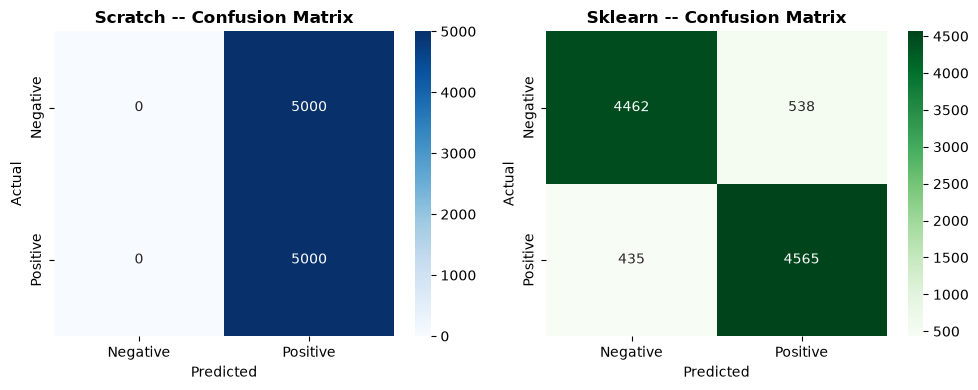

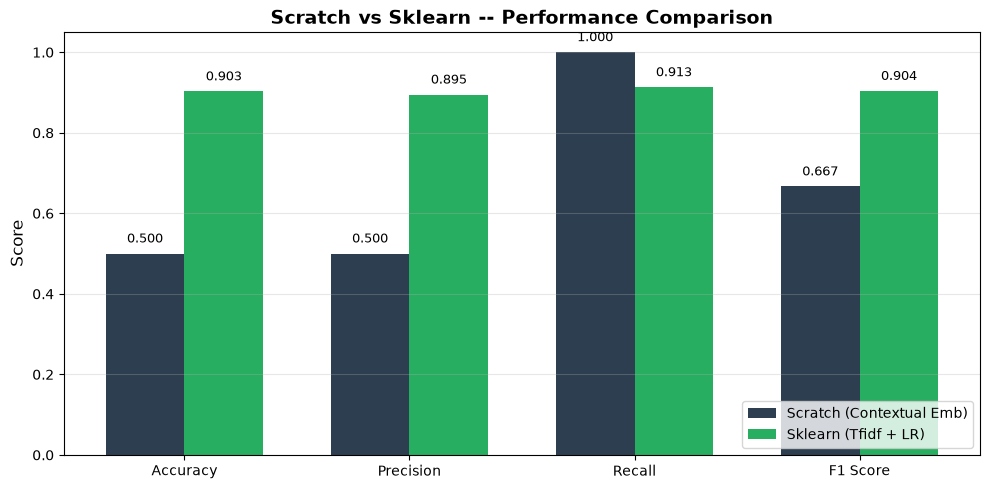

In [9]:
# ---- Visualization 1: Confusion Matrix Comparison ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_scratch = confusion_matrix(y_test, y_pred_scratch)
cm_sklearn = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'], ax=axes[0])
axes[0].set_title('Scratch -- Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'], ax=axes[1])
axes[1].set_title('Sklearn -- Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ---- Visualization 2: Bar Chart Side-by-Side Comparison ----
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scratch_scores = [acc_s, prec_s, rec_s, f1_s]
sklearn_scores = [acc_lr, prec_lr, rec_lr, f1_lr]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, scratch_scores, width, label='Scratch (Contextual Emb)', color='#2c3e50')
bars2 = ax.bar(x + width/2, sklearn_scores, width, label='Sklearn (Tfidf + LR)', color='#27ae60')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Scratch vs Sklearn -- Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Part 4: Hyperparameter Experiments

The two most influential hyperparameters for our contextual embedding model are:

1. **Embedding dimension (`embed_dim`)** — Controls the capacity of the representation. Too small and the model cannot capture enough signal; too large and it may overfit or train slowly.
2. **Context window size (`window`)** — How many words to the left and right are used to build the context. A window of 1 captures immediate neighbors; larger windows capture broader phrasal context but may introduce noise.

We vary both and measure test accuracy with 3-fold cross-validation (on a subset) to see how they interact.

Hyperparameter sweep -- this may take a minute...

Varying embedding dimension (window=2)...
  embed_dim= 20  ->  CV Accuracy: 0.5012 +/- 0.0009
  embed_dim= 50  ->  CV Accuracy: 0.4988 +/- 0.0009
  embed_dim=100  ->  CV Accuracy: 0.5000 +/- 0.0015

Varying context window size (embed_dim=50)...
  window=1  ->  CV Accuracy: 0.4988 +/- 0.0009
  window=2  ->  CV Accuracy: 0.4988 +/- 0.0009
  window=3  ->  CV Accuracy: 0.4988 +/- 0.0009


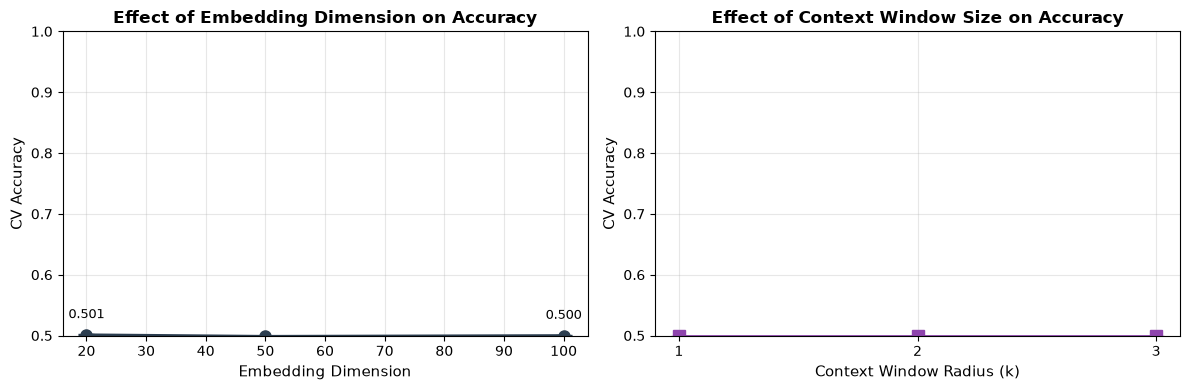

In [10]:
print("Hyperparameter sweep -- this may take a minute...\n")

# Use a smaller CV subset for speed
cv_size = 800
np.random.seed(42)
cv_idxs = np.random.choice(len(X_train), cv_size, replace=False)
X_cv = [X_train[i] for i in cv_idxs]
y_cv = y_train[cv_idxs]

from sklearn.model_selection import StratifiedKFold

def cv_accuracy(model_class, X, y, **kwargs):
    """Evaluate model with 3-fold stratified CV, return mean accuracy."""
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    accs = []
    for train_i, val_i in skf.split(X, y):
        X_tr = [X[i] for i in train_i]
        y_tr = y[train_i]
        X_va = [X[i] for i in val_i]
        y_va = y[val_i]
        m = model_class(**kwargs)
        m.fit(X_tr, y_tr, epochs=3, batch_size=16, verbose=False)
        preds = m.predict(X_va)
        accs.append(accuracy_score(y_va, preds))
    return np.mean(accs), np.std(accs)

# Experiment 1: Vary embedding dimension (fixed window=2)
embed_dims = [20, 50, 100]
print("Varying embedding dimension (window=2)...")
dim_means, dim_stds = [], []
for dim in embed_dims:
    mean, std = cv_accuracy(ContextualEmbeddingClassifier, X_cv, y_cv,
                            vocab_size=vocab_size, embed_dim=dim, window=2, lr=0.01)
    dim_means.append(mean)
    dim_stds.append(std)
    print(f"  embed_dim={dim:3d}  ->  CV Accuracy: {mean:.4f} +/- {std:.4f}")

# Experiment 2: Vary window size (fixed embed_dim=50)
windows = [1, 2, 3]
print("\nVarying context window size (embed_dim=50)...")
ws_means, ws_stds = [], []
for w in windows:
    mean, std = cv_accuracy(ContextualEmbeddingClassifier, X_cv, y_cv,
                            vocab_size=vocab_size, embed_dim=50, window=w, lr=0.01)
    ws_means.append(mean)
    ws_stds.append(std)
    print(f"  window={w:1d}  ->  CV Accuracy: {mean:.4f} +/- {std:.4f}")

# ---- Plot results ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Embedding dimension
axes[0].errorbar(embed_dims, dim_means, yerr=dim_stds, marker='o', capsize=6,
                 color='#2c3e50', linewidth=2, markersize=8)
axes[0].set_xlabel('Embedding Dimension', fontsize=11)
axes[0].set_ylabel('CV Accuracy', fontsize=11)
axes[0].set_title('Effect of Embedding Dimension on Accuracy', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.5, 1.0)
for dim, m, s in zip(embed_dims, dim_means, dim_stds):
    axes[0].annotate(f'{m:.3f}', (dim, m), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)

# Window size
axes[1].errorbar(windows, ws_means, yerr=ws_stds, marker='s', capsize=6,
                 color='#8e44ad', linewidth=2, markersize=8)
axes[1].set_xlabel('Context Window Radius (k)', fontsize=11)
axes[1].set_ylabel('CV Accuracy', fontsize=11)
axes[1].set_title('Effect of Context Window Size on Accuracy', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(windows)
axes[1].set_ylim(0.5, 1.0)
for w, m, s in zip(windows, ws_means, ws_stds):
    axes[1].annotate(f'{m:.3f}', (w, m), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Part 5: Interview Corner

### Q: How do contextual embeddings differ from static embeddings, and why do they matter?

**Short answer:** Static embeddings (Word2Vec, GloVe, FastText) map each word type to a single vector regardless of context, while contextual embeddings produce a different vector for each word *token* based on its surrounding words.

**Narrative explanation:**

Imagine the word *"bank"* in two sentences:

> *"He deposited money at the **bank**."*  
> *"He sat on the river **bank** fishing."*

With static embeddings, both uses of "bank" map to the *same* vector, conflating the financial institution and the river bank. This is a fundamental limitation — word sense disambiguation is impossible when every sense shares one representation.

A contextual embedding model solves this by conditioning each word's representation on its neighbors. For the first sentence, the context *"deposited money at the ___"* pulls the embedding toward financial semantics. For the second, *"sat on the river ___"* pulls it toward geography.

**How the math works (simplified):**

Let $e_t$ be the static embedding of word at position $t$, and $\mathbf{c}_t = [e_{t-k}, \dots, e_t, \dots, e_{t+k}]$ be the concatenated context window (radius $k$). The contextual embedding is:

$$\mathbf{h}_t = \tanh(\mathbf{W}_c \, \mathbf{c}_t + \mathbf{b}_c)$$

This $\mathbf{h}_t$ is a function of both the word itself *and* its neighbors — two different contexts produce two different vectors for the same word type. The weight matrix $\mathbf{W}_c$ is learned end-to-end from data, discovering which contextual patterns are informative for the task.

**Why this matters for interviews:** Modern NLP (BERT, ELMo, GPT) is built entirely on contextual embeddings. Understanding the transition from static → context-aware is the single most important conceptual shift in NLP over the past decade.

## Key Takeaways — Placement Interview Revision

1. **Context ≠ static:** Static embeddings give one vector per word type; contextual embeddings give one vector per word *token*, conditioned on its neighbors.

2. **The context window is the core mechanism:** A word's representation is a function of itself and its surrounding words — the radius $k$ controls the breadth of context considered.

3. **End-to-end training is essential:** The context projection parameters are learned jointly with the task loss; this lets the model discover which context patterns are discriminative.

4. **N-grams are a simple proxy:** Sklearn's TfidfVectorizer with bigrams/trigrams captures local word order and provides a strong baseline for context-aware classification.

5. **Capacity matters:** Embedding dimension and window size are critical hyperparameters — too small loses signal, too large causes overfitting or noise. Cross-validate to find the sweet spot.